In [1]:
import polars as pl
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import ptitprince as pt
import plotly.express as px
from math import pi
sns.set_theme(style='ticks')

In [2]:
study_metadata = pl.read_csv('data/hmp2_metadata_2018-08-20.csv', schema_overrides={'External ID': pl.String}).filter(pl.col('data_type') == 'metagenomics')
study_metadata = study_metadata.select(['External ID', 'Age at diagnosis', 'consent_age', 'sex', 'diagnosis']).with_columns(pl.col("External ID").str.split("_").list.get(0).alias("External ID"))
study_metadata

External ID,Age at diagnosis,consent_age,sex,diagnosis
str,f64,f64,str,str
"""CSM5FZ3N""",28.0,43.0,"""Female""","""CD"""
"""CSM5FZ3R""",28.0,43.0,"""Female""","""CD"""
"""CSM5YRY7""",28.0,43.0,"""Female""","""CD"""
"""CSM5FZ3V""",28.0,43.0,"""Female""","""CD"""
"""CSM5FZ4C""",28.0,43.0,"""Female""","""CD"""
…,…,…,…,…
"""PSMA26A1""",8.0,16.0,"""Female""","""UC"""
"""PSMA26A3""",8.0,16.0,"""Female""","""UC"""
"""PSMB4MC1""",8.0,16.0,"""Female""","""UC"""


In [3]:
ena_metadata = pl.read_csv('data/filereport_read_run_PRJNA398089.tsv', separator='\t').select(['sample_accession', 'experiment_alias'])
ena_metadata = ena_metadata.with_columns(pl.col("experiment_alias").str.split("_").list.get(0).alias("experiment_alias")).join(study_metadata, left_on='experiment_alias', right_on='External ID')

In [4]:
genome_metadata = pl.read_csv('https://swifter.embl.de/~fullam/spire/metadata/spire_v1_genome_metadata.tsv.gz', separator='\t')
genome_metadata = genome_metadata.select(['genome_id', 'domain', 'phylum', 'class', 'order', 'family', 'genus', 'species', 'derived_from_sample', 'n_contigs'])
genome_metadata

genome_id,domain,phylum,class,order,family,genus,species,derived_from_sample,n_contigs
str,str,str,str,str,str,str,str,str,f64
"""spire_mag_00000001""","""Bacteria""","""Actinobacteriota""","""Actinomycetia""","""Actinomycetales""","""Microbacteriaceae""","""Pontimonas""","""Pontimonas sp001438965""","""SAMEA104408696""",153.0
"""spire_mag_00000003""","""Bacteria""","""Proteobacteria""","""Alphaproteobacteria""","""Pelagibacterales""","""Pelagibacteraceae""","""Pelagibacter""","""Pelagibacter sp013204495""","""SAMEA104408696""",124.0
"""spire_mag_00000006""","""Bacteria""","""Chloroflexota""","""Dehalococcoidia""","""UBA1151""","""UBA1328""","""UBA1328""",null,"""SAMEA104408696""",317.0
"""spire_mag_00000007""","""Bacteria""","""Planctomycetota""","""Planctomycetia""","""Planctomycetales""","""Planctomycetaceae""",null,null,"""SAMEA104408696""",813.0
"""spire_mag_00000008""","""Bacteria""","""Planctomycetota""","""UBA8108""","""UBA1146""","""UBA1146""","""JAFMMO01""",null,"""SAMEA104408696""",704.0
…,…,…,…,…,…,…,…,…,…
"""spire_mag_03023324""","""Bacteria""","""Firmicutes_A""","""Clostridia""","""Lachnospirales""","""Lachnospiraceae""","""Clostridium_Q""","""Clostridium_Q fessum""","""SAMEA14100596""",127.0
"""spire_mag_03023325""","""Bacteria""","""Firmicutes_A""","""Clostridia""","""Oscillospirales""","""Oscillospiraceae""","""ER4""","""ER4 sp000765235""","""SAMEA14100468""",34.0
"""spire_mag_03023326""","""Bacteria""","""Firmicutes_A""","""Clostridia""","""Lachnospirales""","""Lachnospiraceae""","""Agathobacter""","""Agathobacter rectalis""","""SAMEA14101339""",181.0


In [5]:
genome_metadata = genome_metadata.join(ena_metadata, left_on='derived_from_sample', right_on='sample_accession')
genome_metadata

genome_id,domain,phylum,class,order,family,genus,species,derived_from_sample,n_contigs,experiment_alias,Age at diagnosis,consent_age,sex,diagnosis
str,str,str,str,str,str,str,str,str,f64,str,f64,f64,str,str
"""spire_mag_00360916""","""Bacteria""","""Proteobacteria""","""Gammaproteobacteria""","""Enterobacterales""","""Enterobacteriaceae""","""Escherichia""","""Escherichia coli""","""SAMN07521601""",595.0,"""HSMA33SG""",null,14.0,"""Female""","""nonIBD"""
"""spire_mag_00360924""","""Bacteria""","""Bacteroidota""","""Bacteroidia""","""Bacteroidales""","""Bacteroidaceae""","""Bacteroides""","""Bacteroides uniformis""","""SAMN07521601""",67.0,"""HSMA33SG""",null,14.0,"""Female""","""nonIBD"""
"""spire_mag_00360925""","""Bacteria""","""Bacteroidota""","""Bacteroidia""","""Bacteroidales""","""Bacteroidaceae""","""Phocaeicola""","""Phocaeicola vulgatus""","""SAMN07521601""",86.0,"""HSMA33SG""",null,14.0,"""Female""","""nonIBD"""
"""spire_mag_00360930""","""Bacteria""","""Proteobacteria""","""Gammaproteobacteria""","""Enterobacterales""","""Pasteurellaceae""","""Haemophilus_D""","""Haemophilus_D sp001815355""","""SAMN07521700""",316.0,"""HSM6XRS6""",15.0,15.0,"""Male""","""CD"""
"""spire_mag_00360931""","""Bacteria""","""Proteobacteria""","""Gammaproteobacteria""","""Burkholderiales""","""Burkholderiaceae""","""Sutterella""","""Sutterella wadsworthensis_A""","""SAMN07521700""",76.0,"""HSM6XRS6""",15.0,15.0,"""Male""","""CD"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""spire_mag_02048099""","""Bacteria""","""Bacteroidota""","""Bacteroidia""","""Bacteroidales""","""Bacteroidaceae""","""Bacteroides""","""Bacteroides uniformis""","""SAMN07532854""",66.0,"""CSM9X215""",28.0,46.0,"""Female""","""UC"""
"""spire_mag_02048102""","""Bacteria""","""Bacteroidota""","""Bacteroidia""","""Bacteroidales""","""Bacteroidaceae""","""Bacteroides""","""Bacteroides finegoldii""","""SAMN07532854""",166.0,"""CSM9X215""",28.0,46.0,"""Female""","""UC"""
"""spire_mag_02048110""","""Bacteria""","""Firmicutes_A""","""Clostridia""","""Lachnospirales""","""Lachnospiraceae""","""Agathobacter""","""Agathobacter faecis""","""SAMN07521692""",53.0,"""CSM67U9B""",30.0,37.0,"""Female""","""CD"""


In [6]:
scores = pl.read_csv('../results/combined_scores.tsv', separator='\t')
scores

taxon,et_score,ca_score,pb_score
str,f64,f64,f64
"""spire_mag_00375920""",-107.891143,0.394737,-0.1
"""spire_mag_00362780""",138.657018,0.473684,0.174603
"""spire_mag_00373296""",-325.408276,0.386598,-0.12
"""spire_mag_00369020""",-33.080922,0.527273,0.103448
"""spire_mag_00366726""",-43.610401,0.346154,-0.031746
…,…,…,…
"""spire_mag_00370395""",-163.742879,0.238994,-0.210526
"""spire_mag_00363470""",-622.763848,0.294686,-0.311475
"""spire_mag_00368645""",328.987187,0.748252,0.17757


In [7]:
joined = scores.join(genome_metadata, left_on='taxon', right_on='genome_id')
joined

taxon,et_score,ca_score,pb_score,domain,phylum,class,order,family,genus,species,derived_from_sample,n_contigs,experiment_alias,Age at diagnosis,consent_age,sex,diagnosis
str,f64,f64,f64,str,str,str,str,str,str,str,str,f64,str,f64,f64,str,str
"""spire_mag_00360916""",-170.057078,0.543478,-0.013333,"""Bacteria""","""Proteobacteria""","""Gammaproteobacteria""","""Enterobacterales""","""Enterobacteriaceae""","""Escherichia""","""Escherichia coli""","""SAMN07521601""",595.0,"""HSMA33SG""",null,14.0,"""Female""","""nonIBD"""
"""spire_mag_00360924""",323.665684,0.424,-0.207547,"""Bacteria""","""Bacteroidota""","""Bacteroidia""","""Bacteroidales""","""Bacteroidaceae""","""Bacteroides""","""Bacteroides uniformis""","""SAMN07521601""",67.0,"""HSMA33SG""",null,14.0,"""Female""","""nonIBD"""
"""spire_mag_00360925""",224.201368,0.526316,0.171429,"""Bacteria""","""Bacteroidota""","""Bacteroidia""","""Bacteroidales""","""Bacteroidaceae""","""Phocaeicola""","""Phocaeicola vulgatus""","""SAMN07521601""",86.0,"""HSMA33SG""",null,14.0,"""Female""","""nonIBD"""
"""spire_mag_00360930""",18.669881,0.432692,-0.022222,"""Bacteria""","""Proteobacteria""","""Gammaproteobacteria""","""Enterobacterales""","""Pasteurellaceae""","""Haemophilus_D""","""Haemophilus_D sp001815355""","""SAMN07521700""",316.0,"""HSM6XRS6""",15.0,15.0,"""Male""","""CD"""
"""spire_mag_00360931""",348.108993,0.44898,-0.045455,"""Bacteria""","""Proteobacteria""","""Gammaproteobacteria""","""Burkholderiales""","""Burkholderiaceae""","""Sutterella""","""Sutterella wadsworthensis_A""","""SAMN07521700""",76.0,"""HSM6XRS6""",15.0,15.0,"""Male""","""CD"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""spire_mag_02048099""",55.846355,0.41958,0.066667,"""Bacteria""","""Bacteroidota""","""Bacteroidia""","""Bacteroidales""","""Bacteroidaceae""","""Bacteroides""","""Bacteroides uniformis""","""SAMN07532854""",66.0,"""CSM9X215""",28.0,46.0,"""Female""","""UC"""
"""spire_mag_02048102""",-5.266678,0.416667,-0.133333,"""Bacteria""","""Bacteroidota""","""Bacteroidia""","""Bacteroidales""","""Bacteroidaceae""","""Bacteroides""","""Bacteroides finegoldii""","""SAMN07532854""",166.0,"""CSM9X215""",28.0,46.0,"""Female""","""UC"""
"""spire_mag_02048110""",175.282018,0.357143,-0.236364,"""Bacteria""","""Firmicutes_A""","""Clostridia""","""Lachnospirales""","""Lachnospiraceae""","""Agathobacter""","""Agathobacter faecis""","""SAMN07521692""",53.0,"""CSM67U9B""",30.0,37.0,"""Female""","""CD"""


In [8]:
df = joined.select(['et_score', 'ca_score', 'pb_score', 'species', 'diagnosis']).to_pandas()

/tmp/ipykernel_5382/3834513828.py:178: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


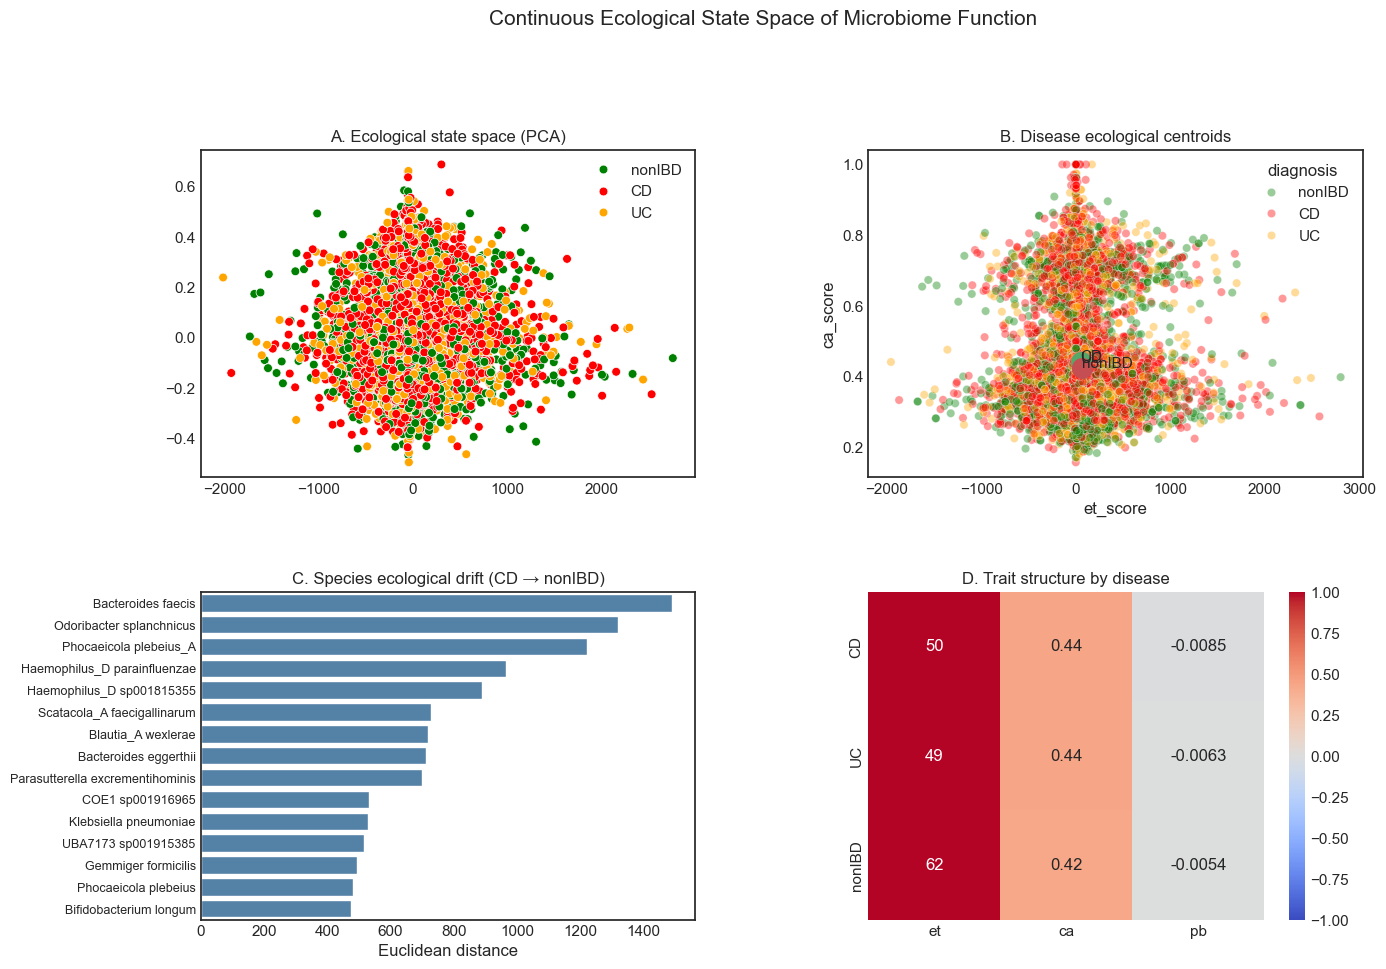

In [9]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# ============================================================
# DATA CLEAN
# ============================================================

df2 = df[["et_score", "ca_score", "pb_score", "species", "diagnosis"]].copy()

df2 = df2.dropna()

df2 = df2.rename(columns={
    "et_score": "et",
    "ca_score": "ca",
    "pb_score": "pb"
})

# ============================================================
# FIGURE SETUP
# ============================================================

plt.style.use("seaborn-v0_8-white")
fig = plt.figure(figsize=(15, 10))
gs = fig.add_gridspec(2, 2, wspace=0.35, hspace=0.35)

# ============================================================
# A. ECOLOGICAL STATE SPACE (PCA)
# ============================================================

ax1 = fig.add_subplot(gs[0, 0])

X = df2[["et", "ca", "pb"]].values

coords = PCA(n_components=2).fit_transform(X)

embed = pd.DataFrame(coords, columns=["PC1", "PC2"])
embed["diagnosis"] = df2["diagnosis"].values

sns.scatterplot(
    data=embed,
    x="PC1",
    y="PC2",
    hue="diagnosis",
    ax=ax1,
    s=40,
    palette={"CD": "red", "UC": "orange", "nonIBD": "green"}
)

ax1.set_title("A. Ecological state space (PCA)")
ax1.set_xlabel("")
ax1.set_ylabel("")
ax1.legend(frameon=False)

# ============================================================
# B. DISEASE CENTROIDS
# ============================================================

ax2 = fig.add_subplot(gs[0, 1])

centroids = df2.groupby("diagnosis")[["et", "ca", "pb"]].mean()

sns.scatterplot(
    data=df2,
    x="et",
    y="ca",
    hue="diagnosis",
    ax=ax2,
    alpha=0.4,
    palette={"CD": "red", "UC": "orange", "nonIBD": "green"}
)

for d in centroids.index:
    ax2.scatter(
        centroids.loc[d, "et"],
        centroids.loc[d, "ca"],
        s=200
    )
    ax2.text(
        centroids.loc[d, "et"],
        centroids.loc[d, "ca"],
        d,
        fontsize=11
    )

ax2.set_title("B. Disease ecological centroids")
ax2.set_xlabel("et_score")
ax2.set_ylabel("ca_score")

# ============================================================
# C. SPECIES ECOLOGICAL DRIFT (FIXED)
# ============================================================

ax3 = fig.add_subplot(gs[1, 0])

pivot = df2.pivot_table(
    index="species",
    columns="diagnosis",
    values=["et", "ca", "pb"],
    aggfunc="mean"
)

drift = []

for s in pivot.index:

    try:
        v_cd = np.array([
            pivot.loc[s, ("et", "CD")],
            pivot.loc[s, ("ca", "CD")],
            pivot.loc[s, ("pb", "CD")]
        ], dtype=float)

        v_nonibd = np.array([
            pivot.loc[s, ("et", "nonIBD")],
            pivot.loc[s, ("ca", "nonIBD")],
            pivot.loc[s, ("pb", "nonIBD")]
        ], dtype=float)

        if np.any(np.isnan(v_cd)) or np.any(np.isnan(v_nonibd)):
            continue

        dist = np.linalg.norm(v_cd - v_nonibd)
        drift.append((s, dist))

    except Exception:
        continue

drift_df = pd.DataFrame(drift, columns=["species", "drift"])
drift_df = drift_df.sort_values("drift", ascending=False).head(15)

sns.barplot(
    data=drift_df,
    x="drift",
    y="species",
    ax=ax3,
    color="steelblue"
)

ax3.set_title("C. Species ecological drift (CD → nonIBD)")
ax3.set_xlabel("Euclidean distance")
ax3.set_ylabel("")
ax3.tick_params(axis="y", labelsize=9)

# ============================================================
# D. TRAIT HEATMAP (BY DISEASE)
# ============================================================

ax4 = fig.add_subplot(gs[1, 1])

heat = df2.groupby("diagnosis")[["et", "ca", "pb"]].mean()

sns.heatmap(
    heat,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    ax=ax4
)

ax4.set_title("D. Trait structure by disease")
ax4.set_xlabel("")
ax4.set_ylabel("")

# ============================================================
# FINAL TITLE
# ============================================================

fig.suptitle(
    "Continuous Ecological State Space of Microbiome Function",
    fontsize=15,
    y=1.02
)

plt.tight_layout()
plt.show()

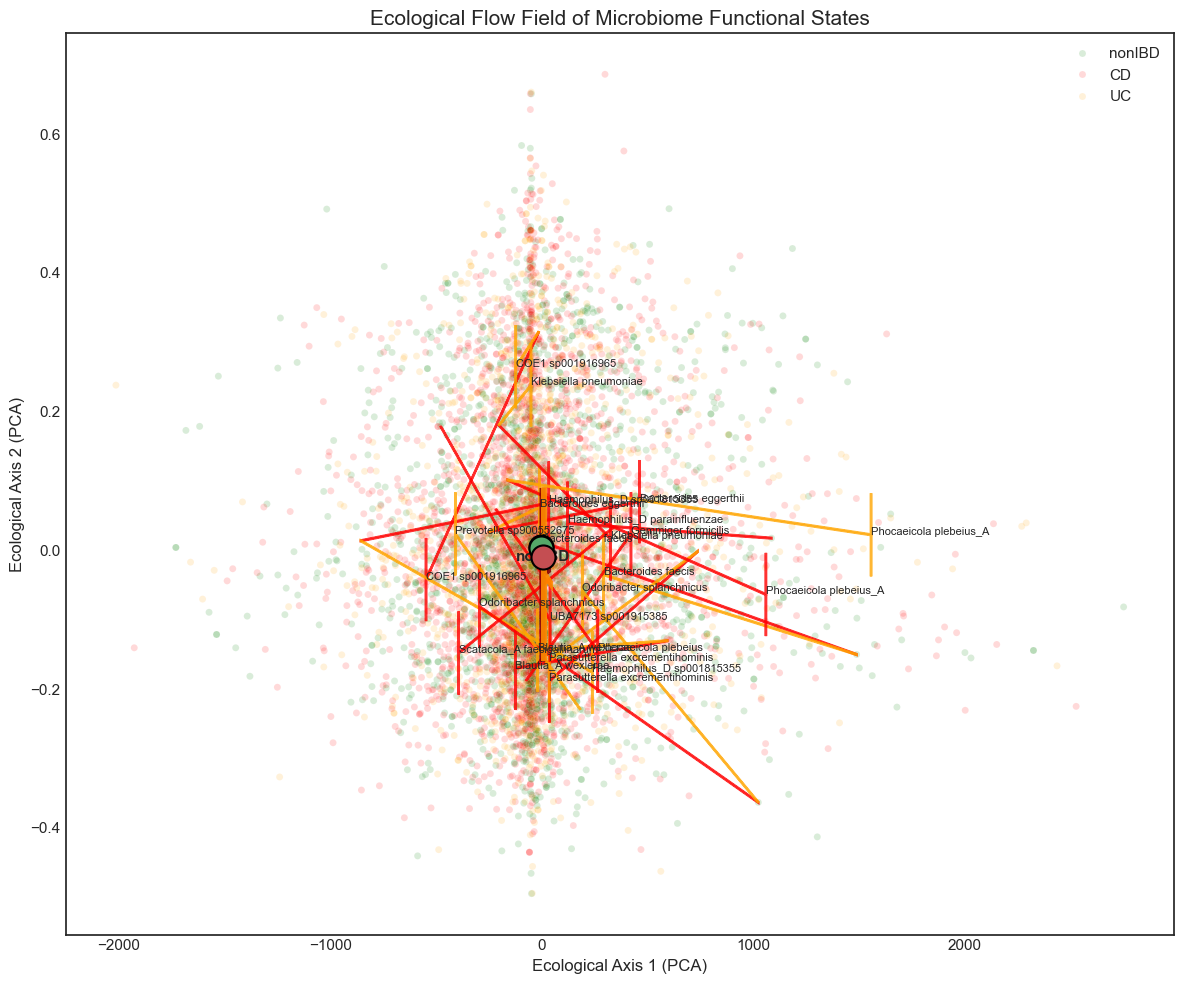

In [10]:
# ============================================================
# DATA PREP
# ============================================================

df2 = df[[
    "et_score",
    "ca_score",
    "pb_score",
    "species",
    "diagnosis"
]].copy()

df2 = df2.dropna()

df2 = df2.rename(columns={
    "et_score": "et",
    "ca_score": "ca",
    "pb_score": "pb"
})

# ============================================================
# PCA ECOLOGICAL SPACE
# ============================================================

features = ["et", "ca", "pb"]

X = df2[features].values

pca = PCA(n_components=2)
coords = pca.fit_transform(X)

embed = pd.DataFrame(coords, columns=["PC1", "PC2"])

embed["species"] = df2["species"].values
embed["diagnosis"] = df2["diagnosis"].values

# ============================================================
# GLOBAL CENTROIDS
# ============================================================

centroids = (
    embed.groupby("diagnosis")[["PC1", "PC2"]]
         .mean()
)

# ============================================================
# SPECIES CENTROIDS PER DISEASE
# ============================================================

species_centroids = (
    embed.groupby(["species", "diagnosis"])[["PC1", "PC2"]]
         .mean()
         .reset_index()
)

# ============================================================
# SPECIES DRIFT VECTORS
# ============================================================

vectors = []

species_list = species_centroids["species"].unique()

for s in species_list:

    sub = species_centroids[
        species_centroids["species"] == s
    ]

    diagnoses = set(sub["diagnosis"])

    # require both healthy and disease state
    if "nonIBD" not in diagnoses:
        continue

    # --------------------------------------------------------
    # CD FLOW
    # --------------------------------------------------------

    if "CD" in diagnoses:

        healthy = sub[sub["diagnosis"] == "nonIBD"].iloc[0]
        disease = sub[sub["diagnosis"] == "CD"].iloc[0]

        vectors.append({
            "species": s,
            "disease": "CD",
            "x0": healthy["PC1"],
            "y0": healthy["PC2"],
            "dx": disease["PC1"] - healthy["PC1"],
            "dy": disease["PC2"] - healthy["PC2"],
            "magnitude": np.linalg.norm([
                disease["PC1"] - healthy["PC1"],
                disease["PC2"] - healthy["PC2"]
            ])
        })

    # --------------------------------------------------------
    # UC FLOW
    # --------------------------------------------------------

    if "UC" in diagnoses:

        healthy = sub[sub["diagnosis"] == "nonIBD"].iloc[0]
        disease = sub[sub["diagnosis"] == "UC"].iloc[0]

        vectors.append({
            "species": s,
            "disease": "UC",
            "x0": healthy["PC1"],
            "y0": healthy["PC2"],
            "dx": disease["PC1"] - healthy["PC1"],
            "dy": disease["PC2"] - healthy["PC2"],
            "magnitude": np.linalg.norm([
                disease["PC1"] - healthy["PC1"],
                disease["PC2"] - healthy["PC2"]
            ])
        })

vectors = pd.DataFrame(vectors)

# ============================================================
# TOP SPECIES BY ECOLOGICAL DISPLACEMENT
# ============================================================

top_species = (
    vectors.groupby("species")["magnitude"]
           .max()
           .sort_values(ascending=False)
           .head(15)
           .index
)

vectors_top = vectors[vectors["species"].isin(top_species)]

# ============================================================
# FIGURE SETUP
# ============================================================

plt.style.use("seaborn-v0_8-white")

fig, ax = plt.subplots(figsize=(12, 10))

# ============================================================
# BACKGROUND ECOLOGICAL SPACE
# ============================================================

sns.scatterplot(
    data=embed,
    x="PC1",
    y="PC2",
    hue="diagnosis",
    alpha=0.15,
    s=25,
    palette={
        "CD": "red",
        "UC": "orange",
        "nonIBD": "green"
    },
    ax=ax,
    legend=True
)

# ============================================================
# GLOBAL DISEASE CENTROIDS
# ============================================================

for d in centroids.index:

    ax.scatter(
        centroids.loc[d, "PC1"],
        centroids.loc[d, "PC2"],
        s=300,
        edgecolor="black",
        linewidth=1.5,
        zorder=5
    )

    ax.text(
        centroids.loc[d, "PC1"],
        centroids.loc[d, "PC2"],
        d,
        fontsize=11,
        weight="bold",
        ha="center",
        va="center"
    )

# ============================================================
# VECTOR FIELD
# ============================================================

for _, r in vectors_top.iterrows():

    color = "red" if r["disease"] == "CD" else "orange"

    ax.arrow(
        r["x0"],
        r["y0"],
        r["dx"],
        r["dy"],
        length_includes_head=True,
        head_width=0.12,
        alpha=0.8,
        linewidth=1.8,
        color=color
    )

    # label arrow endpoint
    ax.text(
        r["x0"] + r["dx"],
        r["y0"] + r["dy"],
        r["species"],
        fontsize=8
    )

# ============================================================
# FLOW FIELD OVERLAY
# ============================================================

# average disease vectors
for disease, color in zip(["CD", "UC"], ["darkred", "darkorange"]):

    sub = vectors[vectors["disease"] == disease]

    if len(sub) == 0:
        continue

    mean_x = sub["x0"].mean()
    mean_y = sub["y0"].mean()

    mean_dx = sub["dx"].mean()
    mean_dy = sub["dy"].mean()

    ax.arrow(
        mean_x,
        mean_y,
        mean_dx,
        mean_dy,
        length_includes_head=True,
        head_width=0.25,
        linewidth=4,
        alpha=0.9,
        color=color
    )

# ============================================================
# FINAL STYLING
# ============================================================

ax.set_title(
    "Ecological Flow Field of Microbiome Functional States",
    fontsize=15
)

ax.set_xlabel("Ecological Axis 1 (PCA)")
ax.set_ylabel("Ecological Axis 2 (PCA)")

ax.legend(frameon=False)

plt.tight_layout()
plt.show()